## Quantum SVM vs Classical SVM on the Iris Dataset

This notebook compares a classical Support Vector Machine (SVM) with a
Quantum Support Vector Machine (QSVM), using the Iris dataset.  

The goal is to explore how quantum feature mapping performs on a small dataset
under simulated quantum conditions.


In [ ]:
# PART 1: Classical SVM

In [ ]:
# 1. Loading Iris Dataset

from sklearn.datasets import load_iris
import numpy as np

iris = load_iris()
X = iris.data
y = iris.target

# Binary classification (class 0 vs class 1)
X = X[y < 2]
y = y[y < 2]

print(f"Samples: {X.shape[0]}, Features: {X.shape[1]}")

Samples: 100, Features: 4


In [ ]:
# 2. Shared Preprocessing

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# 3. Classical SVM

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import time

start_time = time.time()

classical_svm = SVC(kernel="linear")
classical_svm.fit(X_train_scaled, y_train)

classical_predictions = classical_svm.predict(X_test_scaled)
classical_accuracy = accuracy_score(y_test, classical_predictions)

classical_time = time.time() - start_time

print(f"Classical SVM Accuracy: {classical_accuracy:.2f}")
print(f"Training Time: {classical_time:.4f} seconds")

Classical SVM Accuracy: 1.00
Training Time: 0.0057 seconds


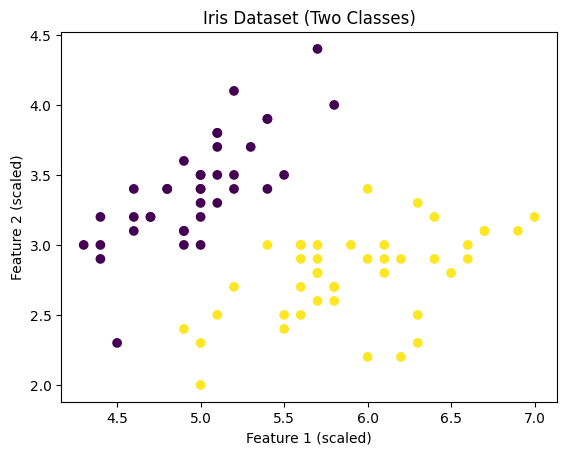

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train)
plt.xlabel("Feature 1 (scaled)")
plt.ylabel("Feature 2 (scaled)")
plt.title("Iris Dataset (Two Classes)")
plt.show()

In [ ]:
# PART 2: Quantum SVM

In [ ]:
# 4. Quantum Support Vector Machine (QSVM) – Simulation

!pip install qiskit qiskit-aer qiskit-machine-learning

In [ ]:
from qiskit.circuit.library import ZZFeatureMap
from qiskit_aer import Aer
from qiskit_machine_learning.kernels import FidelityQuantumKernel

# Configuring Quantum Backend (Simulator)


backend = Aer.get_backend("aer_simulator")

# Preparing Dataset for Quantum Model
# Binary classification (classes 0 and 1 only)
# Using first two features (quantum-friendly)

mask = y < 2
X = X[mask]
y = y[mask]

# Selecting first two features

X = X[:, :2]

print("New feature shape:", X.shape)
print("Unique labels:", np.unique(y))

# Defining Quantum Feature Map
# Encoding classical data into quantum states

feature_map = ZZFeatureMap(
    feature_dimension=2,
    reps=2
)

feature_map

New feature shape: (100, 2)
Unique labels: [0 1]


/tmp/ipython-input-1013783848.py:28: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape)
print("Test samples:", X_test.shape)

# Creating Quantum Kernel
# Measuring similarity between quantum states

from qiskit_machine_learning.kernels import FidelityQuantumKernel

quantum_kernel = FidelityQuantumKernel(
    feature_map=feature_map,
    fidelity=None
)

# Training Quantum SVM using Quantum Kernel

from sklearn.svm import SVC

qsvm = SVC(kernel=quantum_kernel.evaluate)

qsvm.fit(X_train, y_train)

Training samples: (80, 2)
Test samples: (20, 2)


SVC(kernel=<bound method FidelityQuantumKernel.evaluate of <qiskit_machine_learning.kernels.fidelity_quantum_kernel.FidelityQuantumKernel object at 0x7910a79cdb20>>)

In [ ]:
# Comparing Results

from sklearn.metrics import accuracy_score

y_pred_q = qsvm.predict(X_test)

qsvm_accuracy = accuracy_score(y_test, y_pred_q)
print("QSVM Accuracy:", qsvm_accuracy)

from sklearn.svm import SVC

csvm = SVC(kernel="rbf")
csvm.fit(X_train, y_train)

y_pred_c = csvm.predict(X_test)
csvm_accuracy = accuracy_score(y_test, y_pred_c)

print("Classical SVM Accuracy:", csvm_accuracy)

print("==== Model Comparison ====")
print(f"Classical SVM Accuracy: {csvm_accuracy:.2f}")
print(f"Quantum SVM Accuracy:   {qsvm_accuracy:.2f}")

QSVM Accuracy: 0.95
Classical SVM Accuracy: 1.0
==== Model Comparison ====
Classical SVM Accuracy: 1.00
Quantum SVM Accuracy:   0.95


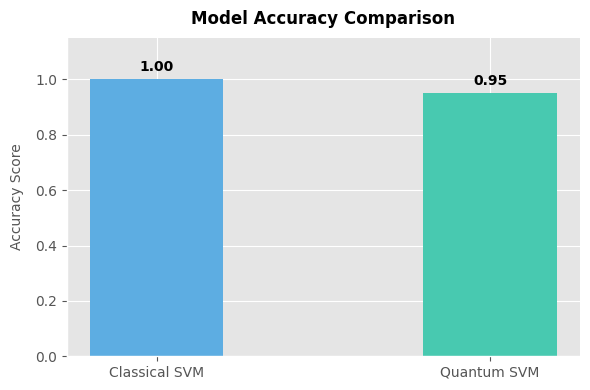

In [194]:
# Data
models = ['Classical SVM', 'Quantum SVM']
accuracies = [csvm_accuracy, qsvm_accuracy]

# Set the style and figure size
plt.figure(figsize=(6, 4))
plt.style.use('ggplot') # Gives a clean, modern look with a subtle grid

# Create bars with custom width and colors
bars = plt.bar(models, accuracies, color=['#5DADE2', '#48C9B0'], width=0.4)

# Improve text and spacing
plt.ylabel('Accuracy Score', fontsize=10, labelpad=8)
plt.title('Model Accuracy Comparison', fontsize=12, pad=10, fontweight='bold')

# SET Y-LIMIT HIGHER: This prevents the "1.0" label from hitting the top border
plt.ylim(0, 1.15)

# Add labels on top of bars with extra padding
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02,
             f'{yval:.2f}', ha='center', va='bottom',
             fontsize=10, fontweight='bold', color='black')

# Remove unnecessary top and right lines for a "magazine" look
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## Personal Reflection

This project helped me understand how classical machine learning techniques can be extended into the quantum domain. While the quantum model did not outperform the classical SVM on the Iris dataset, it provided valuable insights into the limitations and challenges of current quantum machine learning approaches when applied to smaller datasets and simulated environments.
